# Morris Sensitivity Analysis Explainer Demo

In [13]:
import os
import logging

import datatable
import daimojo

from h2o_sonar import interpret
from h2o_sonar.lib.api import commons
from h2o_sonar.lib.api import explainers
from h2o_sonar.explainers import morris_sa_explainer as explainer
from h2o_sonar.lib.api.models import ModelApi

In [14]:
# explainer description
interpret.describe_explainer(explainer.MorrisSensitivityAnalysisExplainer)

{'id': 'h2o_sonar.explainers.morris_sa_explainer.MorrisSensitivityAnalysisExplainer',
 'name': 'MorrisSensitivityAnalysisExplainer',
 'display_name': 'Morris Sensitivity Analysis',
 'tagline': 'MorrisSensitivityAnalysisExplainer.',
 'description': 'Morris sensitivity analysis (SA) explainer provides Morris sensitivity analysis based feature importance which is a measure of the contribution of an input variable to the overall predictions of the model. In applied statistics, the Morris method for global sensitivity analysis is a so-called one-step-at-a-time method (OAT), meaning that in each run only one input parameter is given a new value. This explainer is based based on InterpretML library - see http://interpret.ml',
 'brief_description': 'MorrisSensitivityAnalysisExplainer.',
 'model_types': ['iid'],
 'can_explain': ['regression', 'binomial'],
 'explanation_scopes': ['global_scope'],
 'explanations': [{'explanation_type': 'global-feature-importance',
   'name': 'GlobalFeatImpExplana

## Interpretation

In [15]:
# dataset
dataset_path = "../../data/predictive/pd_ice_creditcard_train.csv"
target_col = "LIMIT_BAL"

# model
mojo_path = "../../data/predictive/models/creditcard-regression.mojo"
mojo_model = daimojo.model(mojo_path)
model = ModelApi().create_model(
    model_src=mojo_model,
    target_col=target_col,
    used_features=list(mojo_model.feature_names),
)

# results
results_location = "./results"
os.makedirs(results_location, exist_ok=True)

In [16]:
# check explainer compatibility before running interpretation
morris_explainer = explainer.MorrisSensitivityAnalysisExplainer()
morris_explainer.logger = logging.getLogger("morris_compatibility_check")

params = commons.CommonInterpretationParams(
    model=model,
    models=[],
    dataset=dataset_path,
    target_col=target_col,
)

is_compatible = morris_explainer.check_compatibility(params=params, model=model)

if not is_compatible:
    error_msg = "Morris Sensitivity Analysis explainer is NOT compatible with this model/dataset.\n\n"
    error_msg += "Possible reasons:\n"
    error_msg += "1. Missing dependencies: interpret==0.1.20 or gevent==1.5.0\n"
    error_msg += "   Install with: pip install interpret==0.1.20 gevent==1.5.0\n"
    error_msg += "2. Model type not supported (H2O-3 models are not compatible)\n"
    error_msg += "3. Model must be regression or binary classification\n\n"
    error_msg += "Cannot continue with interpretation. Please resolve compatibility issues first."
    raise RuntimeError(error_msg)
else:
    print("✓ Morris Sensitivity Analysis explainer is compatible with this model/dataset")

✓ Morris Sensitivity Analysis explainer is compatible with this model/dataset


In [17]:
%%capture
interpretation = interpret.run_interpretation(
    dataset=dataset_path,
    model=model,
    target_col=target_col,
    results_location=results_location,
    explainers=[explainer.MorrisSensitivityAnalysisExplainer.explainer_id()],
    log_level=logging.INFO,
)

## Explainer Result

In [18]:
# retrieve the result
result = interpretation.get_explainer_result(
    explainer.MorrisSensitivityAnalysisExplainer.explainer_id()
)

### Display Data

In [19]:
result.data()

,feature,importance
,▪▪▪▪,▪▪▪▪▪▪▪▪
0,PAY_AMT2,576582
1,BILL_AMT1,483290
2,PAY_AMT6,315424
3,PAY_AMT1,262665
4,PAY_AMT3,250634
5,PAY_AMT5,229284
6,BILL_AMT3,227349
7,PAY_AMT4,226623
8,BILL_AMT4,216030


### Plot Sensitivity Analysis Data

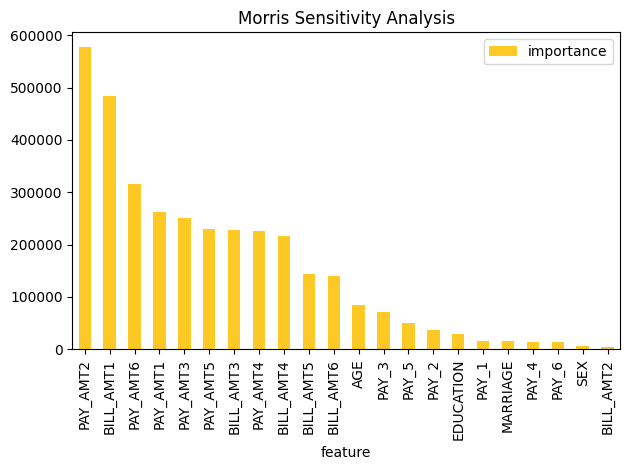

In [20]:
result.plot()

### Save Explainer Log and Data

In [21]:
# save the explainer log
log_file_path = "./morris-sa-demo.log"
result.log(path=log_file_path)

In [22]:
!cat $log_file_path

In [23]:
# save the explainer data
result.zip(file_path="./morris-sa-demo-archive.zip")

In [24]:
!unzip -l morris-sa-demo-archive.zip

Archive:  morris-sa-demo-archive.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
     2217  2026-01-29 16:21   explainer_h2o_sonar_explainers_morris_sa_explainer_MorrisSensitivityAnalysisExplainer_ae200700-113e-45dd-9c07-325067173db7/result_descriptor.json
        2  2026-01-29 16:21   explainer_h2o_sonar_explainers_morris_sa_explainer_MorrisSensitivityAnalysisExplainer_ae200700-113e-45dd-9c07-325067173db7/problems/problems_and_actions.json
      110  2026-01-29 16:21   explainer_h2o_sonar_explainers_morris_sa_explainer_MorrisSensitivityAnalysisExplainer_ae200700-113e-45dd-9c07-325067173db7/global_html_fragment/text_html.meta
      373  2026-01-29 16:21   explainer_h2o_sonar_explainers_morris_sa_explainer_MorrisSensitivityAnalysisExplainer_ae200700-113e-45dd-9c07-325067173db7/global_html_fragment/text_html/explanation.html
    27808  2026-01-29 16:21   explainer_h2o_sonar_explainers_morris_sa_explainer_MorrisSensitivityAnalysisExplainer_ae200700-113e-45dd-9c07